In [1]:
import matplotlib.image as mpimg
import seaborn as sns
import os
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader
import torch
import torchvision
from PIL import Image

In [2]:
base_dir = "./leaves_data/"
train_df = pd.read_csv(os.path.join(base_dir, "train.csv"))
test_df = pd.read_csv(os.path.join(base_dir, "test.csv"))

# 统计每个类别的数量，并观察数据集
label_counts = train_df['label'].value_counts()
print('各类别数量', '\n',label_counts, '\n')
print(train_df.head(5))

各类别数量 
 label
maclura_pomifera            353
ulmus_rubra                 235
prunus_virginiana           223
acer_rubrum                 217
broussonettia_papyrifera    214
                           ... 
cedrus_deodara               58
ailanthus_altissima          58
crataegus_crus-galli         54
evodia_daniellii             53
juniperus_virginiana         51
Name: count, Length: 176, dtype: int64 

          image             label
0  images/0.jpg  maclura_pomifera
1  images/1.jpg  maclura_pomifera
2  images/2.jpg  maclura_pomifera
3  images/3.jpg  maclura_pomifera
4  images/4.jpg  maclura_pomifera


In [3]:
# 查看训练集数据
print(train_df.shape,'\n')
print(train_df.describe(),'\n')
train_df.info()

(18353, 2) 

               image             label
count          18353             18353
unique         18353               176
top     images/0.jpg  maclura_pomifera
freq               1               353 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18353 entries, 0 to 18352
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   18353 non-null  object
 1   label   18353 non-null  object
dtypes: object(2)
memory usage: 286.9+ KB


C:\Users\OMEN\AppData\Local\Temp\ipykernel_30580\107011611.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.countplot(y=train_df['label'],order=label_counts.index,palette="RdYlGn")


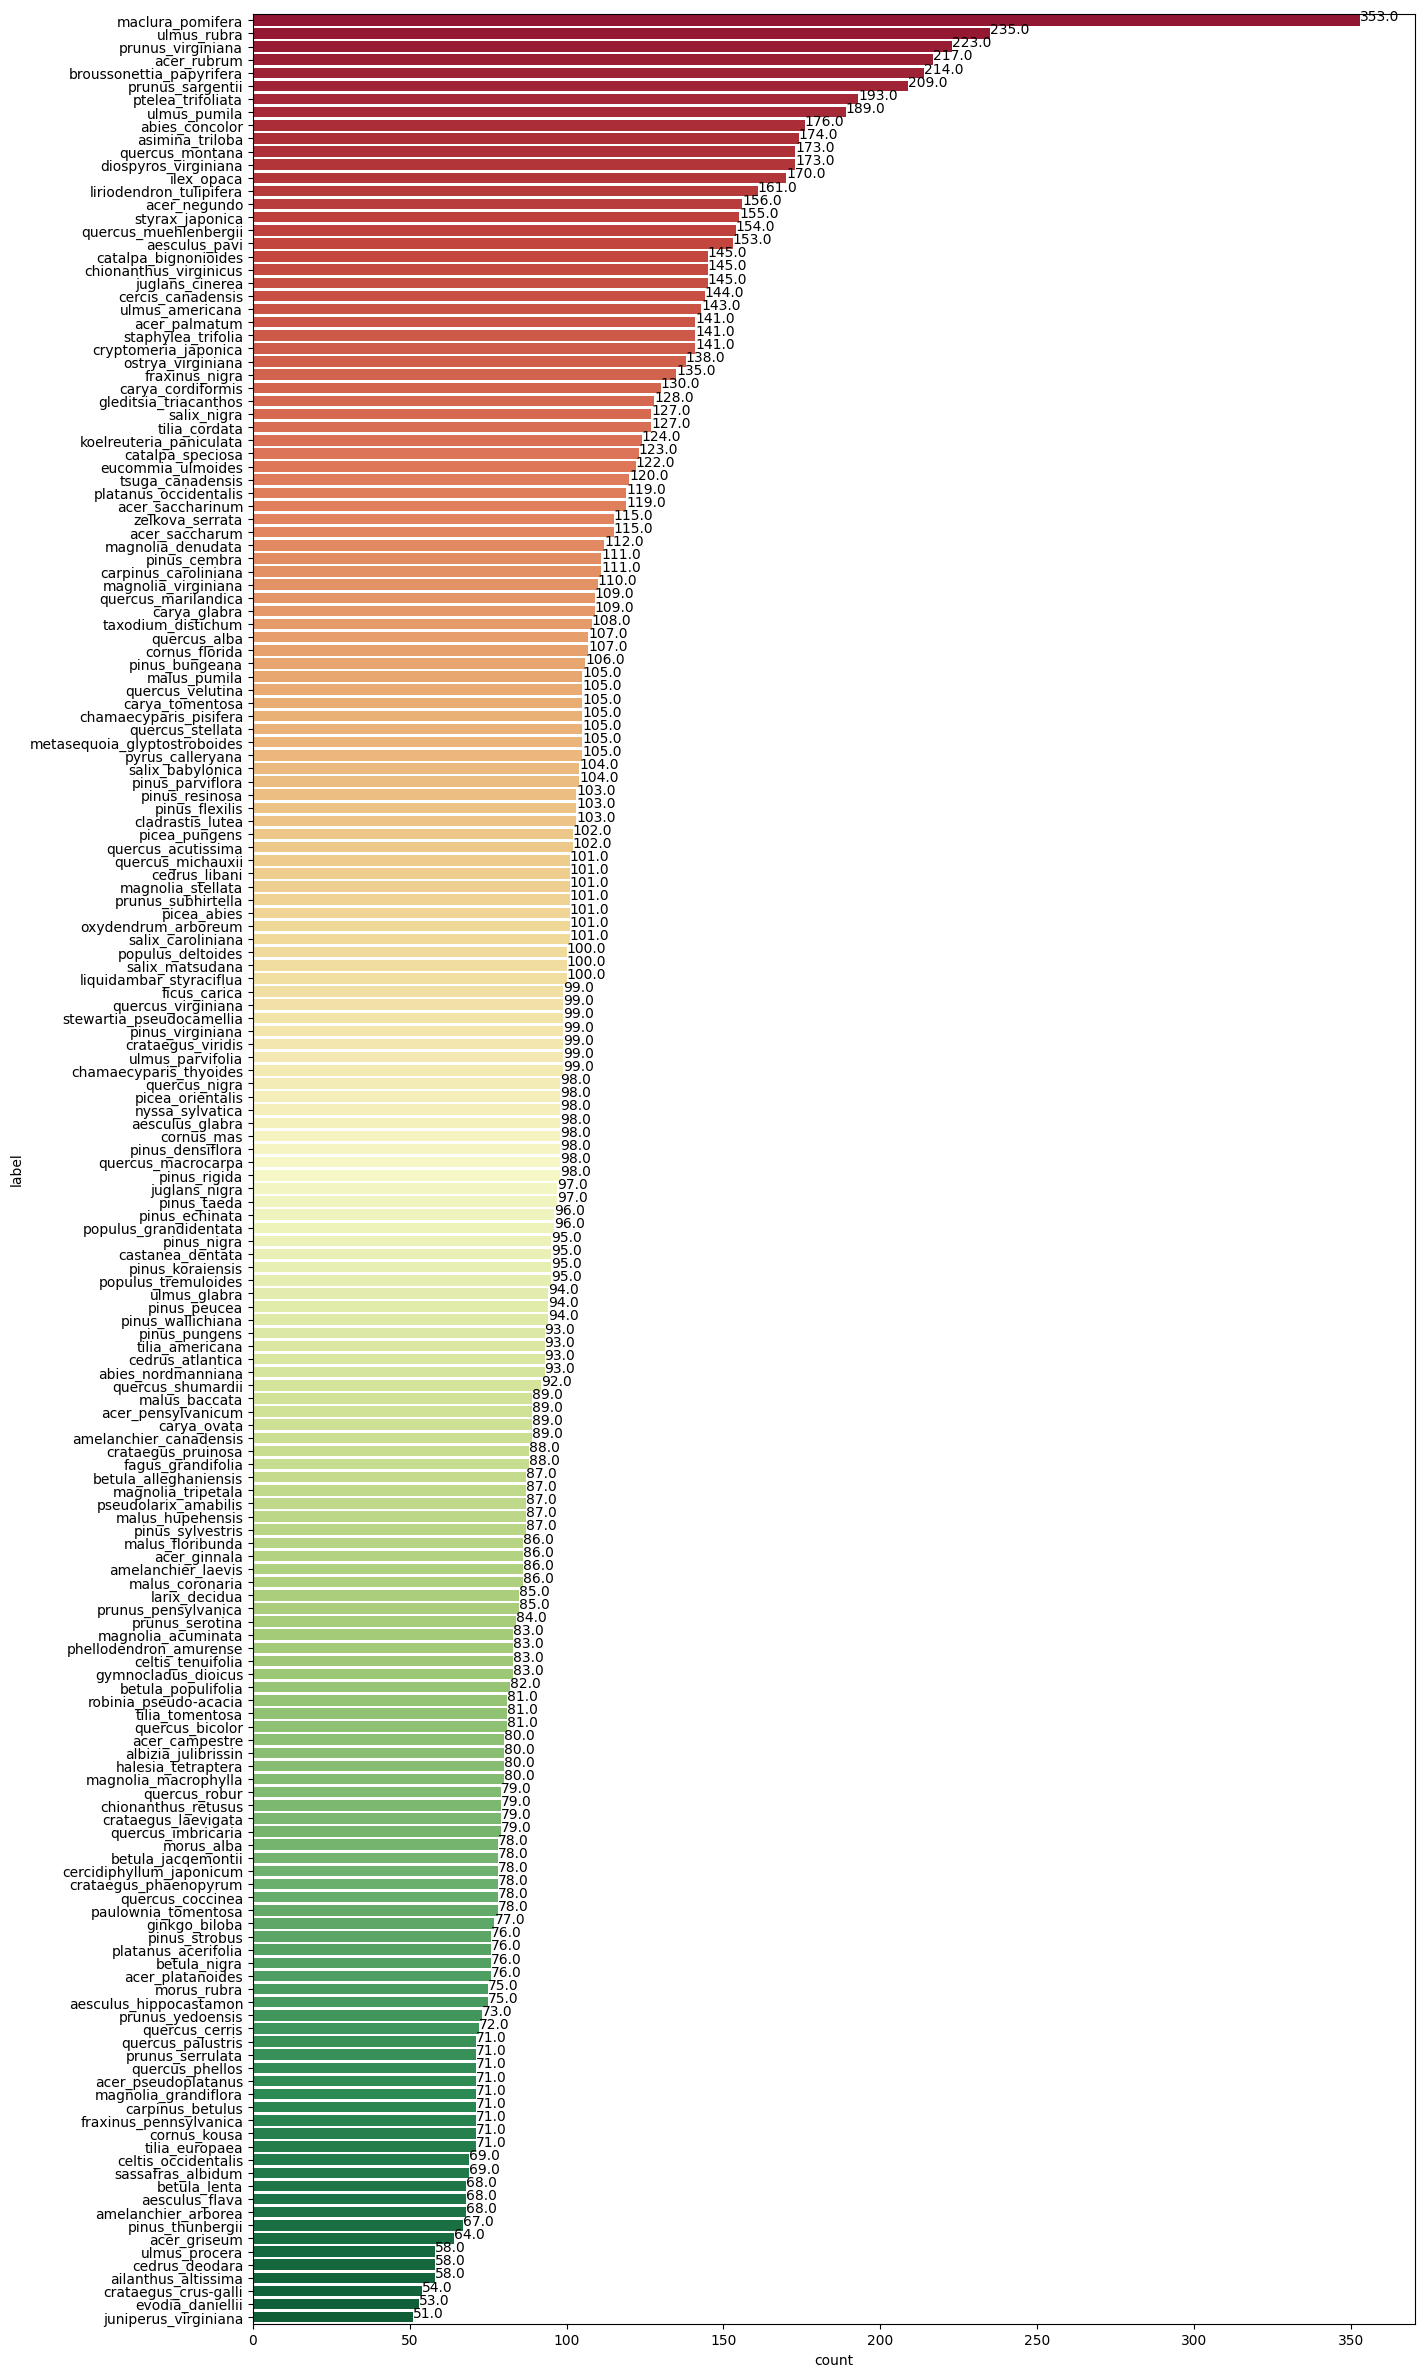

In [4]:
# 显示每个类别数量的柱状图
def barw(ax): 
    
    for p in ax.patches:
        val = p.get_width()
        x = p.get_x()+ p.get_width()
        y = p.get_y() + p.get_height()/2
        ax.annotate(round(val,2),(x,y))
        
plt.figure(figsize = (15,30))
ax =sns.countplot(y=train_df['label'],order=label_counts.index,palette="RdYlGn")
barw(ax)
plt.show()

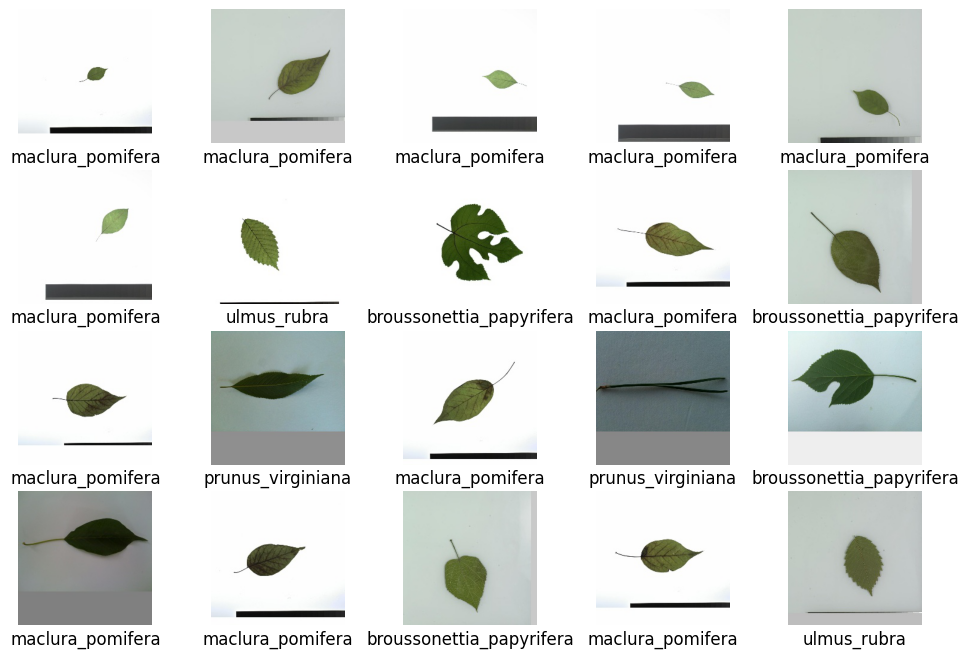

In [5]:
# 查看前20张图片
preview_image_paths = train_df['image'][:20]
preview_image_labels = train_df['label'][:20]
# 创建子图
fig, axes = plt.subplots(4,5, figsize=(12, 8))

for i,(ax,img_path) in enumerate(zip(axes.flatten(),preview_image_paths)):
    img = mpimg.imread(os.path.join(base_dir, "raw_images", img_path.split('/')[-1]))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(preview_image_labels[i],y=-0.2)

plt.show()

In [6]:
unique_labels = train_df["label"].unique()
label_idx = {label: idx for idx, label in enumerate(unique_labels)}

class LeaveDataset(Dataset):
    def __init__(self, data_df, transform=None):
        self.data = data_df
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(base_dir, 'raw_images', self.data.iloc[idx,0].split('/')[-1])
        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)  # 图片增广
        
        label_name = self.data.iloc[idx,1]
        label = label_idx[label_name]  # 转换为整数索引

        return image, label
    
train_dataset = LeaveDataset(train_df, transform=torchvision.transforms.ToTensor())

def compute_mean_std(dataset, batch_size=128, num_workers=0):
    """计算数据集RGB三通道的总体均值和标准差"""                                     
    loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    sum_pixel = torch.zeros(3, dtype=torch.float64)
    sum_square = torch.zeros(3, dtype=torch.float64)
    total_pixels = 0

    for images, _ in loader:
        images = images.double()
        sum_pixel += images.sum(dim=[0, 2, 3])
        sum_square += (images ** 2).sum(dim=[0, 2, 3])
        total_pixels += images.size(0) * images.size(2) * images.size(3)

    mean = sum_pixel / total_pixels
    var = sum_square / total_pixels - mean ** 2
    std = torch.sqrt(var)

    return mean.float(), std.float()
mean, std = compute_mean_std(train_dataset)
print(mean,std)

tensor([0.7579, 0.7780, 0.7590]) tensor([0.2479, 0.2348, 0.2630])
